In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv('/kidney_disease.csv')

In [ ]:
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             329 non-null    float64
 17  wc              294 non-null    flo

In [ ]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [ ]:
df.columns = df.columns.str.strip().str.replace('\t', '', regex=True)

In [ ]:
df.drop(columns=['id'], inplace=True)

In [ ]:
num_cols_to_fix = ['pcv', 'wc', 'rc']
for col in num_cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df_encoded.drop(columns=['classification_notckd'])
y = 1 - df_encoded['classification_notckd']

In [ ]:
print(list(df_encoded.columns))

['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'rbc_normal', 'pc_normal', 'pcc_present', 'ba_present', 'htn_yes', 'dm_\tyes', 'dm_no', 'dm_yes', 'cad_no', 'cad_yes', 'appet_poor', 'pe_yes', 'ane_yes', 'classification_ckd\t', 'classification_notckd']


In [ ]:
print("Features used for training:")
print(list(X.columns))

Features used for training:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'rbc_normal', 'pc_normal', 'pcc_present', 'ba_present', 'htn_yes', 'dm_\tyes', 'dm_no', 'dm_yes', 'cad_no', 'cad_yes', 'appet_poor', 'pe_yes', 'ane_yes', 'classification_ckd\t']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **K-Nearest Neighbors**


In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
cv_knn = cross_val_score(knn, scaler.fit_transform(X), y, cv=10, scoring='accuracy')

In [ ]:
print("\nKNN")
print(f"Accuracy: {acc_knn:.4f}")
print(f"Cross-Validation Mean Accuracy: {cv_knn.mean():.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")


KNN
Accuracy: 0.9750
Cross-Validation Mean Accuracy: 0.9800
Confusion Matrix:
[[30  0]
 [ 2 48]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



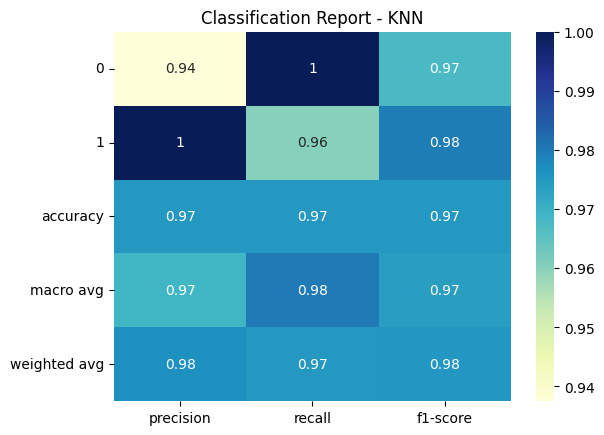

In [ ]:
import seaborn as sns
cr_knn = classification_report(y_test, y_pred_knn, output_dict=True)
sns.heatmap(pd.DataFrame(cr_knn).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report - KNN")
plt.show()

# **Decision Tree**

In [ ]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [ ]:
grid_dt = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

In [ ]:
print("\nDecision Tree")
print(f"Accuracy: {acc_dt:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_dt)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_dt)}")


Decision Tree
Accuracy: 0.9750
Confusion Matrix:
[[30  0]
 [ 2 48]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



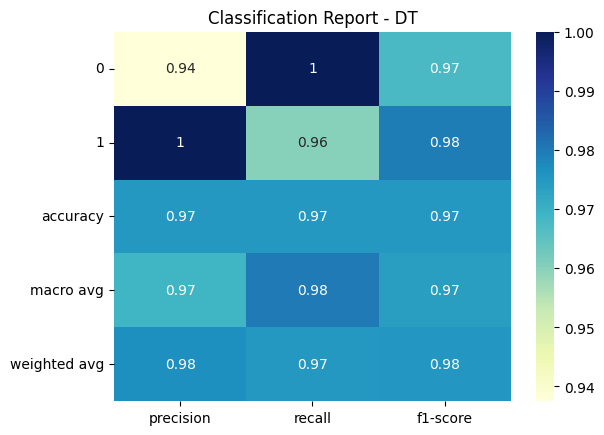

In [ ]:
cr_dt = classification_report(y_test, y_pred_dt, output_dict=True)
sns.heatmap(pd.DataFrame(cr_dt).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report - DT")
plt.show()

In [ ]:
print("Features used for training:")
print(list(X.columns))

Features used for training:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'rbc_normal', 'pc_normal', 'pcc_present', 'ba_present', 'htn_yes', 'dm_\tyes', 'dm_no', 'dm_yes', 'cad_no', 'cad_yes', 'appet_poor', 'pe_yes', 'ane_yes', 'classification_ckd\t']


# **Naives bayes**

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

In [ ]:
print("\nNaive Bayes")
print(f"Accuracy: {acc_nb:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_nb)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_nb)}")


Naive Bayes
Accuracy: 0.9625
Confusion Matrix:
[[30  0]
 [ 3 47]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       1.00      0.94      0.97        50

    accuracy                           0.96        80
   macro avg       0.95      0.97      0.96        80
weighted avg       0.97      0.96      0.96        80



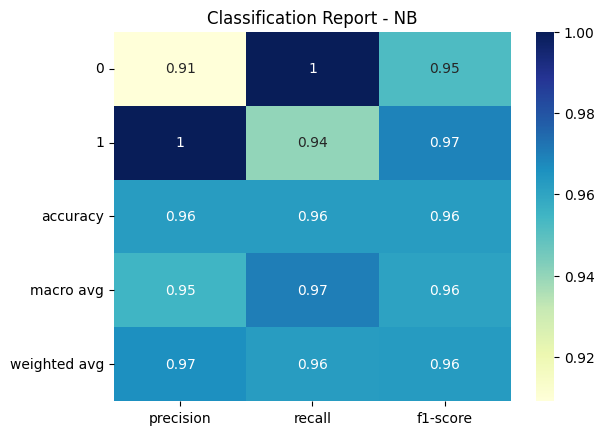

In [ ]:
cr_nb = classification_report(y_test, y_pred_nb, output_dict=True)
sns.heatmap(pd.DataFrame(cr_nb).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report - NB")
plt.show()

# **Support vector machine**

In [ ]:
svm = SVC(kernel='rbf', C=5, gamma=0.01)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

In [ ]:
print("\nSVM")
print(f"Accuracy: {acc_svm:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svm)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svm)}")


SVM
Accuracy: 0.9750
Confusion Matrix:
[[30  0]
 [ 2 48]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



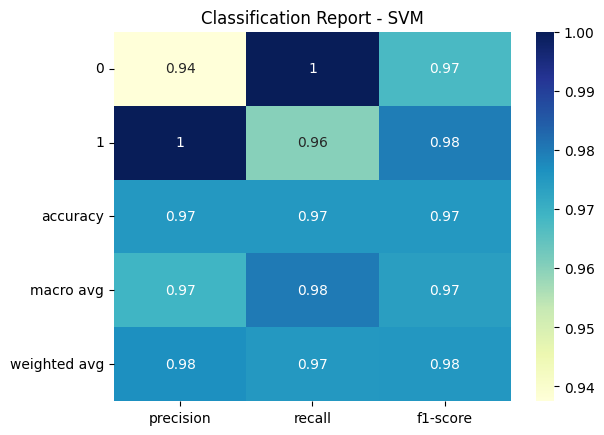

In [ ]:
cr_svm = classification_report(y_test, y_pred_svm, output_dict=True)
sns.heatmap(pd.DataFrame(cr_svm).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report - SVM")
plt.show()

# **Ada Boost**

In [ ]:
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1))
adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)

In [ ]:
print("\nAdaBoost")
print(f"Accuracy: {acc_ada:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_ada)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_ada)}")


AdaBoost
Accuracy: 0.9625
Confusion Matrix:
[[30  0]
 [ 3 47]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       1.00      0.94      0.97        50

    accuracy                           0.96        80
   macro avg       0.95      0.97      0.96        80
weighted avg       0.97      0.96      0.96        80



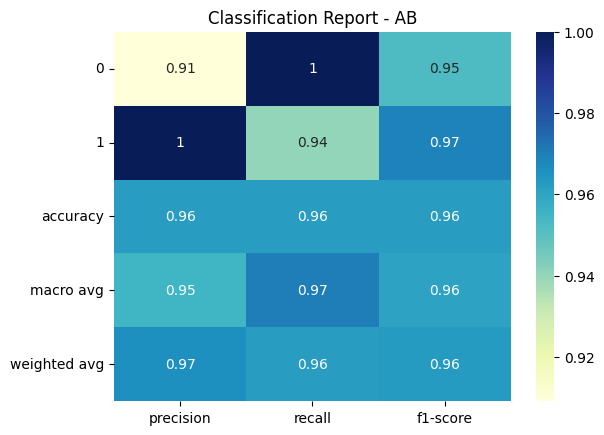

In [ ]:
cr_ab = classification_report(y_test, y_pred_ada, output_dict=True)
sns.heatmap(pd.DataFrame(cr_ab).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report - AB")
plt.show()

# **XG Boost**

In [ ]:
xgb = XGBClassifier(objective='binary:logistic', learning_rate=0.5, max_depth=5, n_estimators=150)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

In [ ]:
print("\nXGBoost")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_xgb)}")


XGBoost
Accuracy: 0.9875
Confusion Matrix:
[[29  1]
 [ 0 50]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



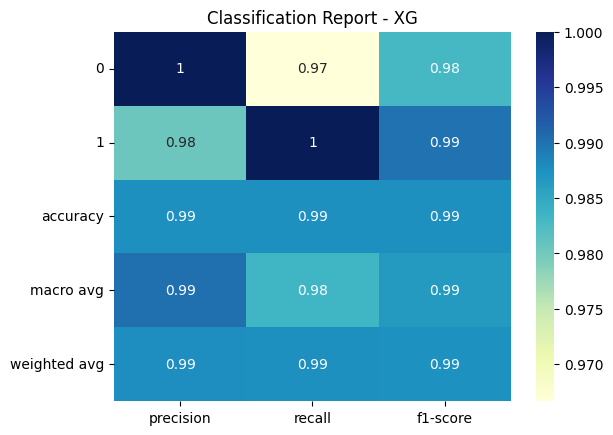

In [ ]:
cr_xg = classification_report(y_test, y_pred_xgb, output_dict=True)
sns.heatmap(pd.DataFrame(cr_xg).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report - XG")
plt.show()

#**Random Forest**

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

In [ ]:
print("\nRandom Forest")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")


Random Forest
Accuracy: 1.0000
Confusion Matrix:
[[30  0]
 [ 0 50]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



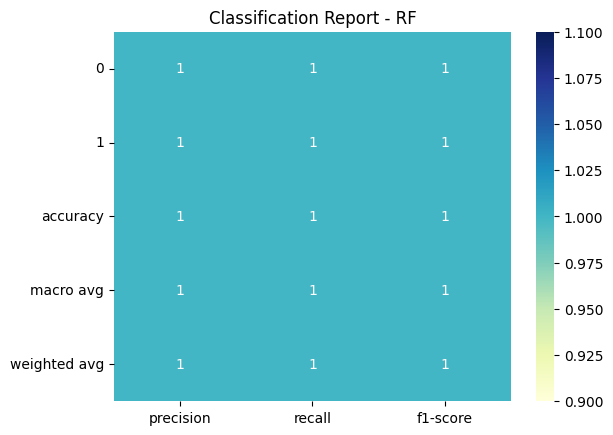

In [ ]:
cr_rf = classification_report(y_test, y_pred_rf, output_dict=True)
sns.heatmap(pd.DataFrame(cr_rf).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report - RF")
plt.show()

#**Model Comparison**

In [ ]:
import seaborn as sns

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
model_names = ["KNN", "Decision Tree", "Naive Bayes", "SVM", "Ada Boost", "XGBoost", "Random Forest"]
performance_data = {
    "Model": model_names,
    "Accuracy": [
        acc_knn, acc_dt, acc_nb, acc_svm, acc_ada, acc_xgb, acc_rf
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_rf),
    ],
    "Precision": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_ada),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_rf),
    ],
    "Recall": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_ada),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_rf),
    ],
}
performance_df = pd.DataFrame(performance_data)


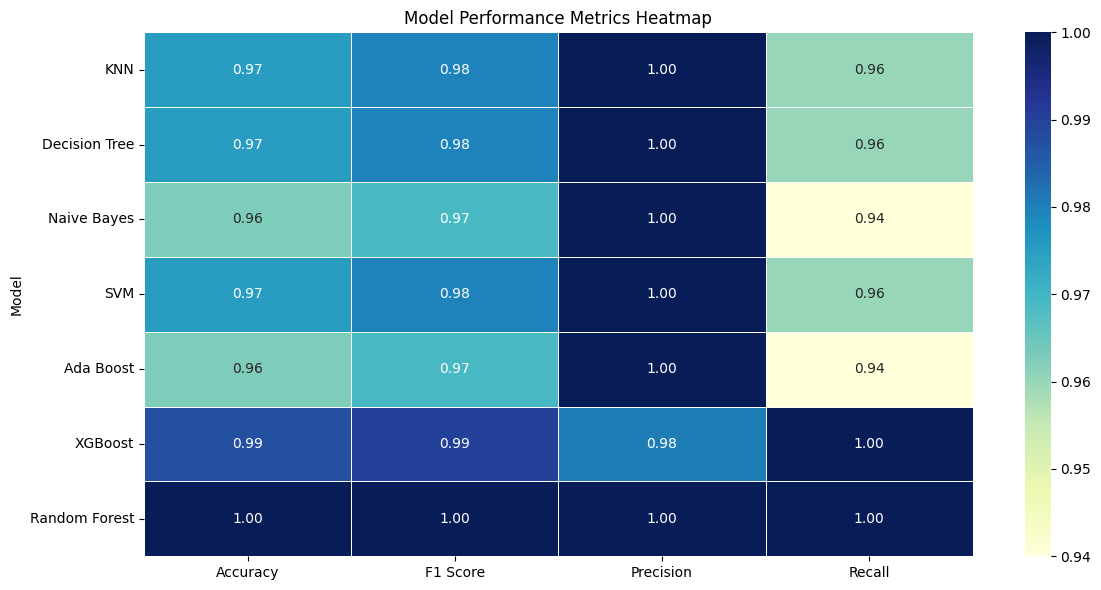

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(performance_df.set_index("Model"), annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Model Performance Metrics Heatmap")
plt.tight_layout()
plt.show()


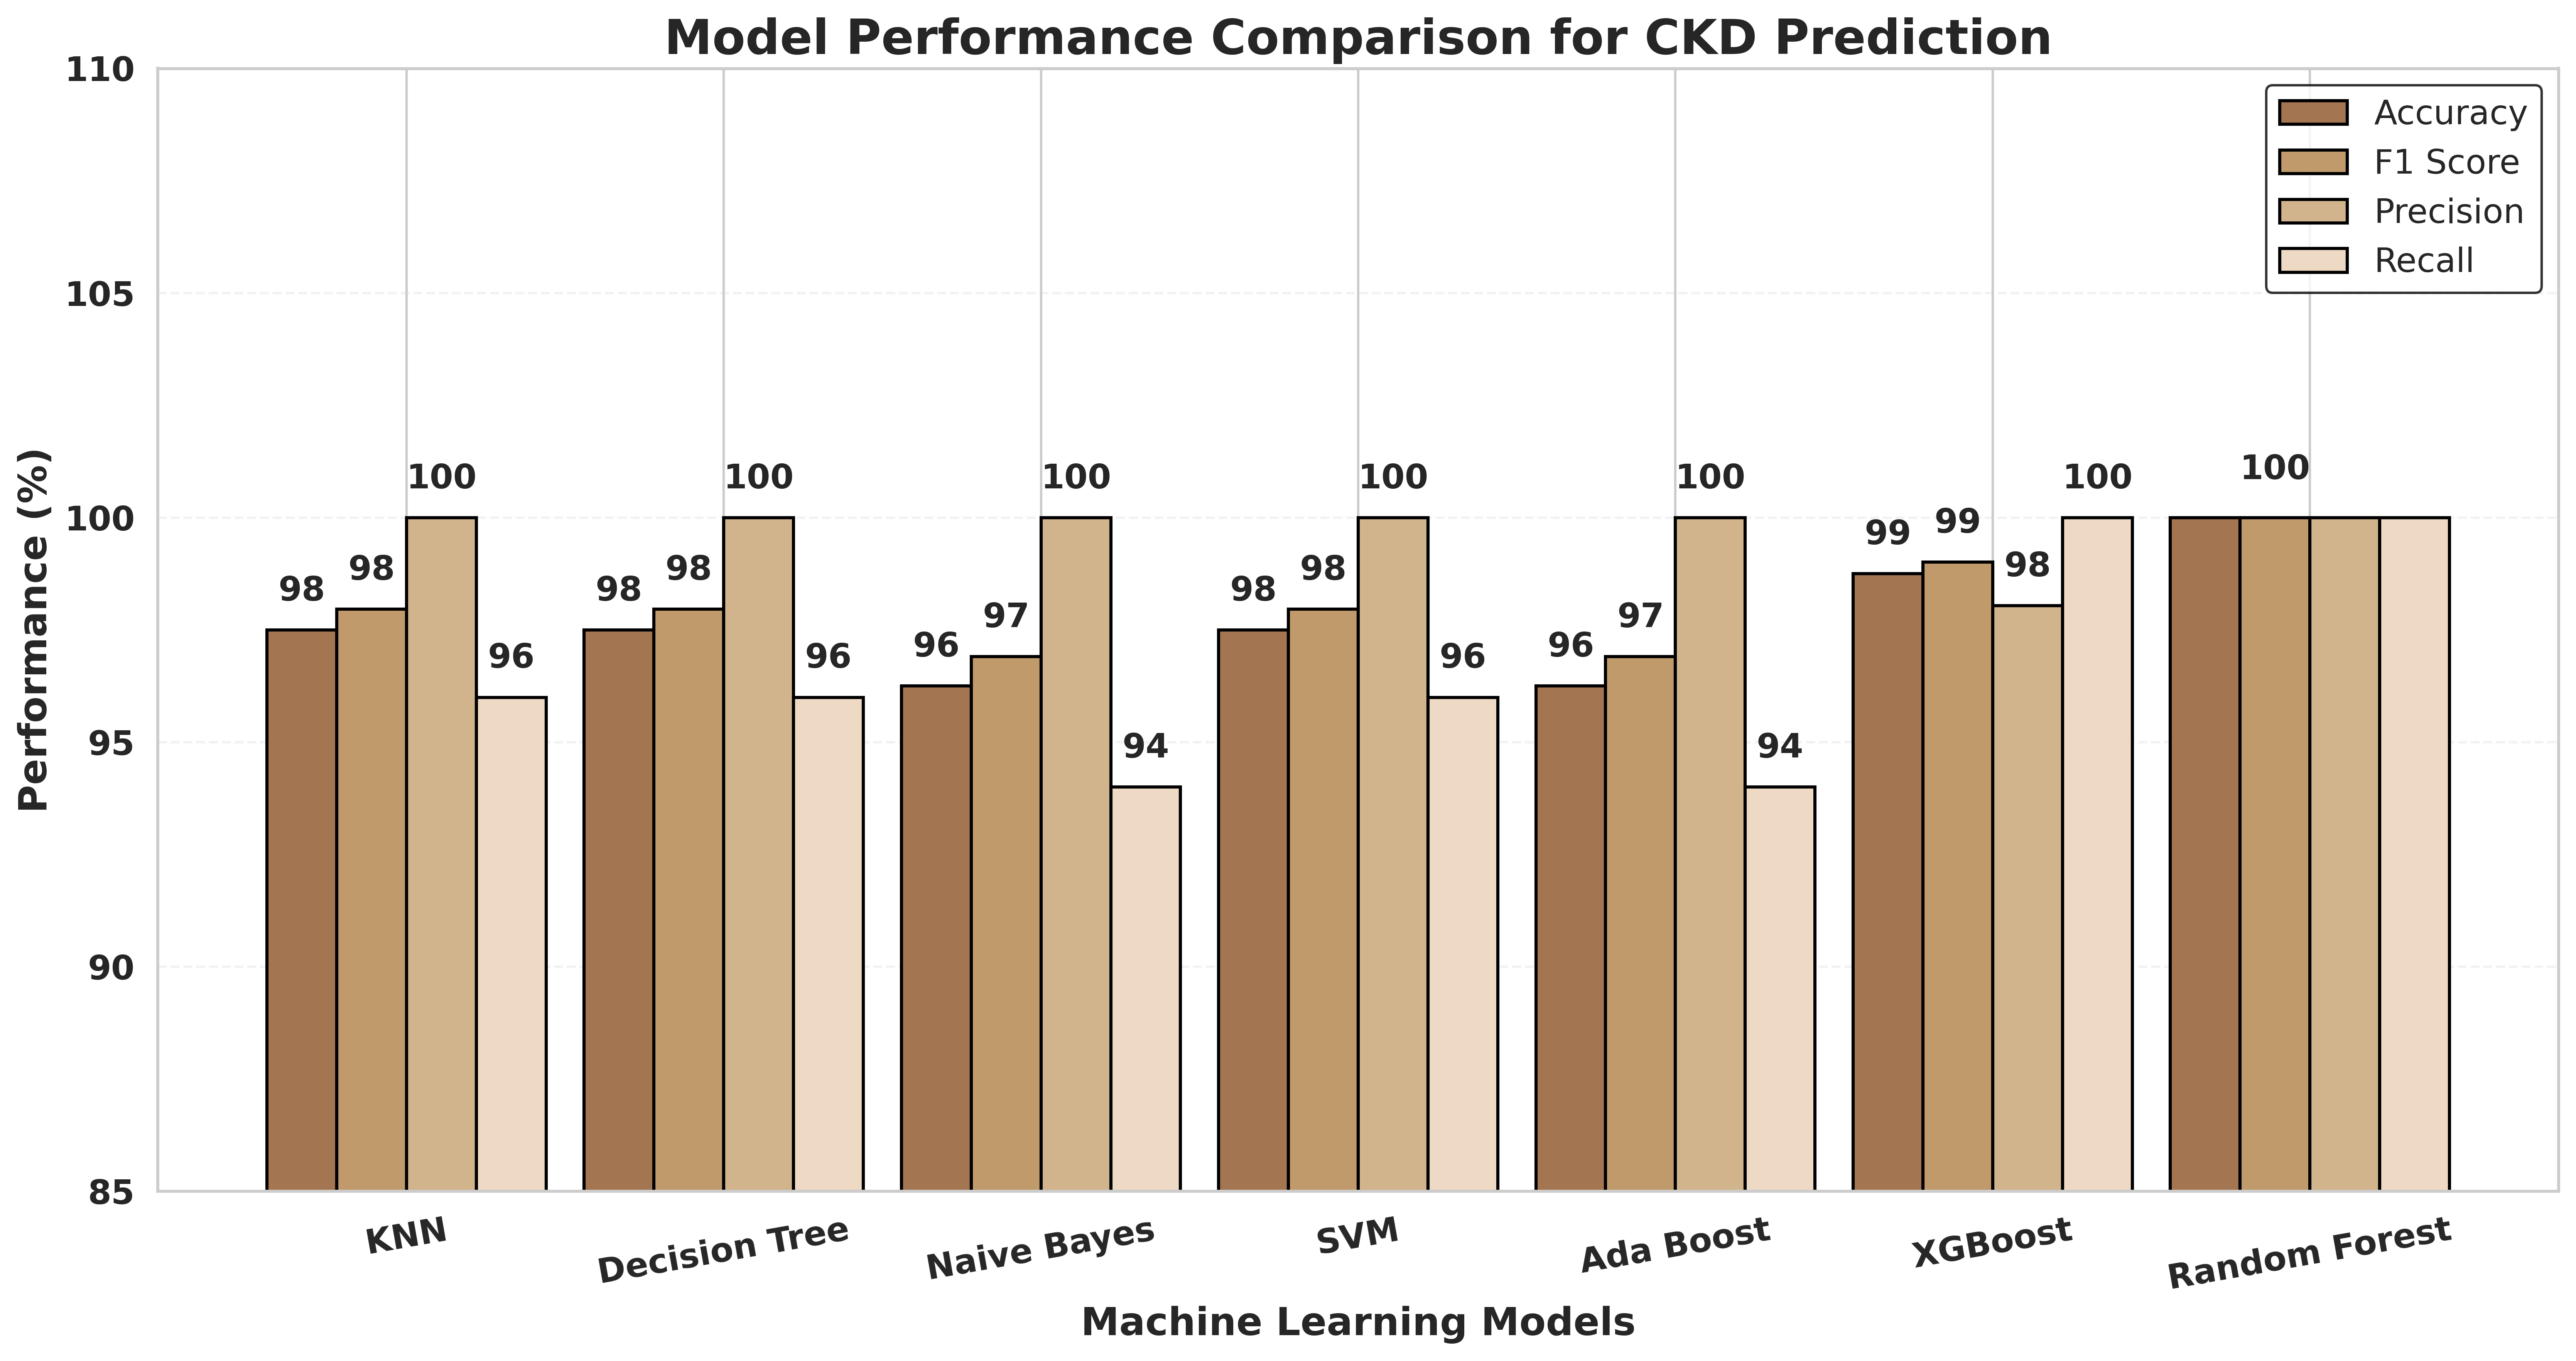

In [ ]:
# Convert to percentage values
pdf = performance_df.copy()
pdf[["Accuracy", "F1 Score", "Precision", "Recall"]] *= 100

x = np.arange(len(pdf["Model"]))
bar_width = 0.22

plt.figure(figsize=(15, 8), dpi=450)

# Pastel brown palette
colors = ['#A47551', '#C19A6B', '#D2B48C', '#EED9C4']

bars1 = plt.bar(x - 0.33, pdf["Accuracy"], width=bar_width, color=colors[0],
                edgecolor='black', linewidth=1.3, label='Accuracy')
bars2 = plt.bar(x - 0.11, pdf["F1 Score"], width=bar_width, color=colors[1],
                edgecolor='black', linewidth=1.3, label='F1 Score')
bars3 = plt.bar(x + 0.11, pdf["Precision"], width=bar_width, color=colors[2],
                edgecolor='black', linewidth=1.3, label='Precision')
bars4 = plt.bar(x + 0.33, pdf["Recall"], width=bar_width, color=colors[3],
                edgecolor='black', linewidth=1.3, label='Recall')


def add_labels_smart():
    for idx in range(len(pdf)):
        scores = pdf.iloc[idx, 1:5].values  # extract 4 metric values
        bars = [bars1[idx], bars2[idx], bars3[idx], bars4[idx]]

        if len(set(scores)) == 1:  # all same → print only once
            avg_x = bars2[idx].get_x() + bar_width/2   # center of group
            plt.text(avg_x, scores[0] + 0.7, f"{scores[0]:.0f}",
                     ha='center', va='bottom', fontsize=14, fontweight='bold')
        else:
            # print individually above bars
            for bar, score in zip(bars, scores):
                plt.text(bar.get_x() + bar.get_width()/2, score + 0.5,
                         f"{score:.0f}", ha='center', va='bottom',
                         fontsize=14, fontweight='bold')

add_labels_smart()


plt.xlabel("Machine Learning Models", fontsize=16, fontweight='bold')
plt.ylabel("Performance (%)", fontsize=16, fontweight='bold')
plt.title("Model Performance Comparison for CKD Prediction",
          fontsize=20, fontweight='bold')

plt.xticks(x, pdf["Model"], fontsize=14, fontweight='bold', rotation=10)
plt.yticks(fontsize=14, fontweight='bold')
plt.ylim(85, 110)   # enough headroom for a single label

plt.grid(axis='y', linestyle='--', alpha=0.25)
plt.legend(fontsize=14, frameon=True, edgecolor='black')
plt.tight_layout()
plt.show()


/tmp/ipython-input-1186370003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


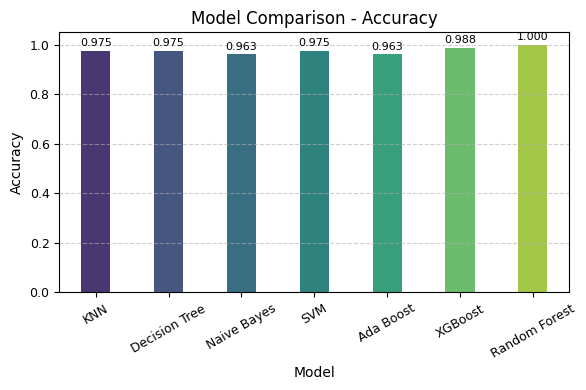

/tmp/ipython-input-1186370003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


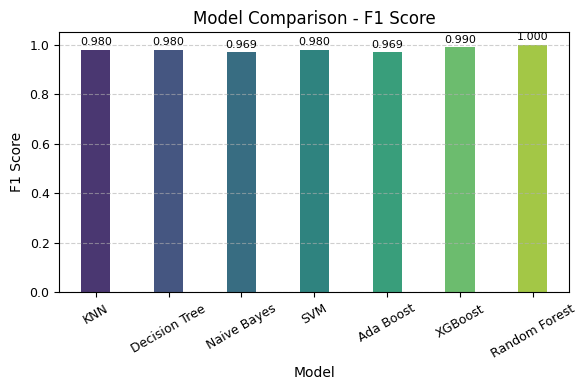

/tmp/ipython-input-1186370003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


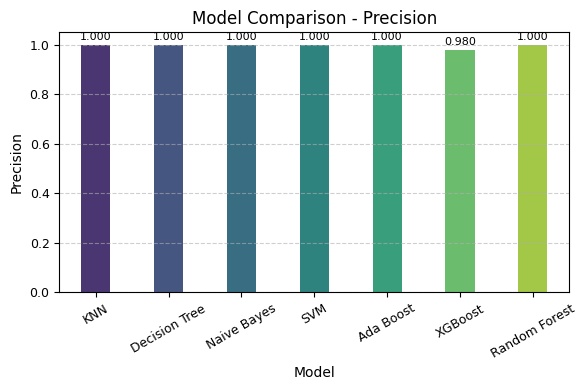

/tmp/ipython-input-1186370003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


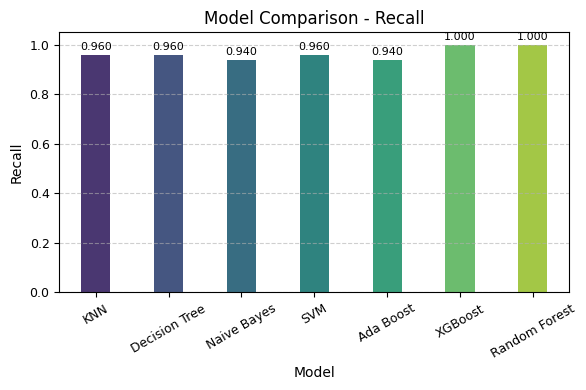

In [ ]:
metrics = ["Accuracy", "F1 Score", "Precision", "Recall"]

for metric in metrics:
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(
        x="Model",
        y=metric,
        data=performance_df,
        palette="viridis",
        width=0.4
    )
    for p in ax.patches:
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_height() + 0.01,
            f"{p.get_height():.3f}",
            ha='center', va='bottom', fontsize=8
        )

    plt.title(f"Model Comparison - {metric}", fontsize=12)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, axis='y', linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


research paper


In [ ]:
df_encoded.corr()['classification_notckd'].sort_values()


,classification_notckd
al,-0.599238
htn_yes,-0.590438
dm_yes,-0.552866
bgr,-0.401374
appet_poor,-0.393341
pe_yes,-0.375154
bu,-0.372033
su,-0.327812
ane_yes,-0.325396
sc,-0.294079


In [ ]:
corr_matrix = X.corr().abs()
np.fill_diagonal(corr_matrix.values, 0)
print((corr_matrix > 0.99).any())


age                     False
bp                      False
sg                      False
al                      False
su                      False
bgr                     False
bu                      False
sc                      False
sod                     False
pot                     False
hemo                    False
pcv                     False
wc                      False
rc                      False
rbc_normal              False
pc_normal               False
pcc_present             False
ba_present              False
htn_yes                 False
dm_\tyes                False
dm_no                   False
dm_yes                  False
cad_no                  False
cad_yes                 False
appet_poor              False
pe_yes                  False
ane_yes                 False
classification_ckd\t    False
dtype: bool


In [ ]:
cross_val_score(rf, X, y, cv=10).mean()


np.float64(0.99)

In [ ]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf, X, y, cv=10, scoring='accuracy')
print("Random Forest 10-fold CV Accuracy:", rf_cv.mean())
print("Standard Deviation:", rf_cv.std())


Random Forest 10-fold CV Accuracy: 0.99
Standard Deviation: 0.016583123951777013


In [ ]:
# --- same code as before up to plotting ---
plt.figure(figsize=(10,6))
sns.set(style="whitegrid")

order = res_df['Model']

ax = sns.barplot(
    x='Model',
    y='CV Mean',
    data=res_df,
    order=order,
    palette="viridis",
    ci=None
)

# Add error bars
x_positions = np.arange(len(res_df))
y = res_df['CV Mean'].values
yerr = res_df['CV Std'].values
ax.errorbar(x=x_positions, y=y, yerr=yerr, fmt='none', ecolor='k', elinewidth=1.5, capsize=6)

# === New annotation block ===
# Choose a fixed y-position slightly above the highest bar (e.g., 1.01)
y_text = res_df['CV Mean'].max() + 0.02

for i, (mean, std) in enumerate(zip(y, yerr)):
    ax.text(
        i, y_text, f"{mean:.3f} ± {std:.3f}",
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='black'
    )

# make everything neat
ax.set_ylim(0.85, 1.05)  # adjust if needed
ax.set_ylabel("10-Fold CV Accuracy", fontsize=12, fontweight='bold')
ax.set_xlabel("")
ax.set_title("Cross-Validation Accuracy (Mean ± SD)", fontsize=14, fontweight='bold')
plt.xticks(rotation=30, fontsize=10, fontweight='bold')
sns.despine()
plt.tight_layout()

plt.savefig("cv_accuracy_comparison_fixedlabels.png", dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'res_df' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
from PIL import Image
import os

# path to folder where confusion matrices are saved
folder = "confusion_matrices"
files = [
    "KNN_confusion_matrix.png",
    "Decision_Tree_confusion_matrix.png",
    "Naive_Bayes_confusion_matrix.png",
    "SVM_confusion_matrix.png",
    "AdaBoost_confusion_matrix.png",
    "XGBoost_confusion_matrix.png",
    "Random_Forest_confusion_matrix.png"
]
images = [Image.open(os.path.join(folder, f)) for f in files]

# combine horizontally or in a grid
cols = 4
rows = 2
thumb_w, thumb_h = images[0].size
combined = Image.new("RGB", (cols * thumb_w, rows * thumb_h), (255, 255, 255))

for idx, img in enumerate(images):
    x = (idx % cols) * thumb_w
    y = (idx // cols) * thumb_h
    combined.paste(img, (x, y))

combined.save("combined_confusion_matrices.png")
combined.show()
